<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/convolution_neural_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
print(device)

cuda


In [4]:
# Hyperparameters
num_epochs = 10
learning_rate = 0.001
batch_size = 32

In [5]:
# define what transforms we want to apply
# dataset has PILImages in range [0,1]
# Normalize these tensor values between -1 and 1
# For 3 channels, we provide mean and standard deviation of 0.5
pil_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
    ]
)

In [6]:
print(pil_transform)

Compose(
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)


In [7]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    download=True,
    train=True,
    transform=pil_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    download=True,
    train=False,
    transform=pil_transform
)
print(train_dataset.classes)

print(train_dataset.data.shape)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
(50000, 32, 32, 3)


In [8]:
print(len(train_dataset.classes))

10


In [9]:
# There are 50,000 images
# Each image is of size 32x32, this is the pixel value
# Each pixel has 3 channels
# N, H, W, C - Number of images, height, width, channels
# Compared with MNIST dataset - we have extra argument channel here
# MNIST dataset had grayscale images - each pixel value had only 1 channel
# This channel had value either 0 or 1  - black or white, activated or not
# MNIST size: (50000, 28, 28)
# CIFAR size: (50000, 32, 32, 3)

In [10]:
train_dataloader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_dataloader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [11]:
print(train_dataloader.dataset.data.shape)

(50000, 32, 32, 3)


In [12]:
print(test_dataloader.dataset.data.shape)

(10000, 32, 32, 3)


In [13]:
# Helper function to show what's in the dataset
def imshow(imgs):
    # imgs = imgs / 2 + 0.5   # unnormalize
    npimgs = imgs.numpy()
    plt.imshow(np.transpose(npimgs, (1, 2, 0)))
    plt.show()



torch.Size([32, 3, 32, 32])
torch.Size([32])


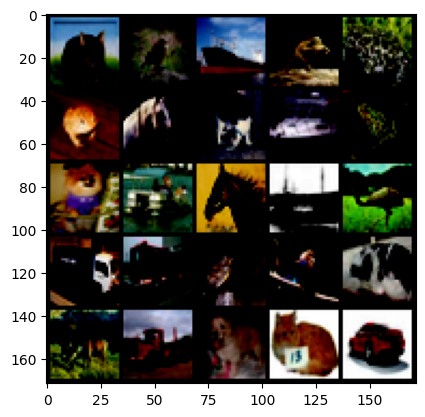

In [14]:
# one batch of random training images
dataiter = iter(train_dataloader)
print(dataiter)
images, labels = next(dataiter)
print(images.shape)
print(labels.shape)
img_grid = torchvision.utils.make_grid(images[0:25], nrow=5)
imshow(img_grid)

torch.Size([32, 3, 32, 32])
torch.Size([32])


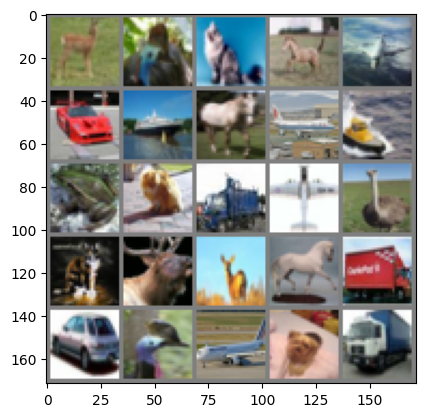

In [15]:
# Helper function to show what's in the dataset
def imshow(imgs):
    imgs = imgs / 2 + 0.5   # unnormalize
    npimgs = imgs.numpy()
    plt.imshow(np.transpose(npimgs, (1, 2, 0)))
    plt.show()

# one batch of random training images
dataiter = iter(train_dataloader)
print(dataiter)
images, labels = next(dataiter)
print(images.shape)
print(labels.shape)
img_grid = torchvision.utils.make_grid(images[0:25], nrow=5)
imshow(img_grid)

In [16]:
import torch.nn.functional as F

In [17]:
# Create the neural network
class ConvolutionNeuralNetwork(nn.Module):
  def __init__(self):
     super(ConvolutionNeuralNetwork, self).__init__()
     self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
     self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
     self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
     # Flatten 3D tensor into 1D tensor before applying Linear layer
     # Size of 1D tensor is 16*5*5
     self.fc1 = nn.Linear(in_features=16*5*5, out_features=120)
     self.fc2 = nn.Linear(in_features=120, out_features=84)
     #  10 classes
     self.fc3 = nn.Linear(in_features=84, out_features=10)

  def forward(self,x):
    # First layer: n, 3, 32, 32
    x = F.relu(self.pool(self.conv1(x))) # n, 6, 14, 14
    # Second layer
    x = F.relu(self.pool(self.conv2(x))) # n, 16, 5, 5
    # Third layer - flatten the tensor from 3D to 2D
    x = x.view(-1, 16*5*5)
    x = F.relu(self.fc1(x)) # n, 16*5*5, 120
    # Fourth layer
    x = F.relu(self.fc2(x)) # n, 120, 84
    # No activation, because we are using CrossEntropyLoss which does that
    x = self.fc3(x) # n, 84, 10
    return x


In [18]:
# Create the neural network
class ConvNet(nn.Module):
  def __init__(self):
     super(ConvNet, self).__init__()
     # ((W - F + 2P) / S) + 1 -> (32 - 3)/1 + 1 = 30
     self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
     self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
     # ((W - F + 2P) / S) + 1 -> (15 - 3)/1 + 1 = 13
     self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
     # ((W - F + 2P) / S) + 1 -> (6 - 3)/1 + 1 = 4
     self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3)
     # Flatten 3D tensor into 1D tensor before applying Linear layer, no pooling
     # Size of 1D tensor is 16*4*4
     self.fc1 = nn.Linear(in_features=64*4*4, out_features=64)
     #  10 classes
     self.fc2 = nn.Linear(in_features=64, out_features=10)

  def forward(self,x):
    # First layer: n, 3, 32, 32
    x = F.relu(self.pool(self.conv1(x))) # n, 32, 15, 15
    # Second layer
    x = F.relu(self.pool(self.conv2(x))) # n, 64, 6, 6
    # Third layer, no pooling
    x = F.relu(self.conv3(x)) # n, 64, 4, 4
    # Third layer - flatten the tensor from 3D to 2D
    x = x.view(-1, 64*4*4) # n, 1024
    x = F.relu(self.fc1(x)) # n, 1024, 64
    # No activation, because we are using CrossEntropyLoss which does that
    x = self.fc2(x) # n, 64, 10
    return x


In [19]:
# model = ConvolutionNeuralNetwork().to(device)
model = ConvNet().to(device)

In [20]:
print(model)

ConvNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [22]:
# (((W - F) + 2P)/ S) + 1 - convolution layer result

In [23]:
n_total_steps = len(train_dataloader)
print(n_total_steps)

1563


In [24]:
# 50,000 images in a batch of 32 = 1563

In [25]:
for epoch in range(num_epochs):
  running_loss = 0.0
  for i, (images, labels) in enumerate(train_dataloader):
    # Original shape: n, 3, 32, 32 = n, 3, 32*32 = n, 3, 1024
    # Input layer: in_channels = 3, out_channels = 32, kernel_size = 3
    # Move them all to GPU
    images = images.to(device)
    labels= labels.to(device)

    # Forward pass
    outputs = model(images)

    # Loss
    loss = criterion(outputs, labels)

    # Back propagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Zero gradient
    optimizer.zero_grad()

    running_loss += loss.item()
    # Average loss for each epoch

  print(f"Epoch ({epoch+1}/{num_epochs}), Loss ({running_loss/n_total_steps:.3f})")


print('Finished training')
# Save model?
PATH = './cnn.pth'
torch.save(model.state_dict(), PATH)

Epoch (1/10), Loss (1.478)
Epoch (2/10), Loss (1.109)
Epoch (3/10), Loss (0.952)
Epoch (4/10), Loss (0.847)
Epoch (5/10), Loss (0.771)
Epoch (6/10), Loss (0.713)
Epoch (7/10), Loss (0.665)
Epoch (8/10), Loss (0.619)
Epoch (9/10), Loss (0.577)
Epoch (10/10), Loss (0.542)
Finished training


In [26]:
# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())


Model's state_dict:
conv1.weight 	 torch.Size([32, 3, 3, 3])
conv1.bias 	 torch.Size([32])
conv2.weight 	 torch.Size([64, 32, 3, 3])
conv2.bias 	 torch.Size([64])
conv3.weight 	 torch.Size([64, 64, 3, 3])
conv3.bias 	 torch.Size([64])
fc1.weight 	 torch.Size([64, 1024])
fc1.bias 	 torch.Size([64])
fc2.weight 	 torch.Size([10, 64])
fc2.bias 	 torch.Size([10])


In [27]:
# Load the model
# First load the architecture
loaded_model = ConvNet()
print(loaded_model)


ConvNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [28]:
# Then load the weights
print(loaded_model.load_state_dict(torch.load(PATH)))

<All keys matched successfully>


In [29]:
# Print loaded model's state_dict
print("Loaded model's state_dict:")
for param_tensor in loaded_model.state_dict():
    print(param_tensor, "\t", loaded_model.state_dict()[param_tensor].size())


Loaded model's state_dict:
conv1.weight 	 torch.Size([32, 3, 3, 3])
conv1.bias 	 torch.Size([32])
conv2.weight 	 torch.Size([64, 32, 3, 3])
conv2.bias 	 torch.Size([64])
conv3.weight 	 torch.Size([64, 64, 3, 3])
conv3.bias 	 torch.Size([64])
fc1.weight 	 torch.Size([64, 1024])
fc1.bias 	 torch.Size([64])
fc2.weight 	 torch.Size([10, 64])
fc2.bias 	 torch.Size([10])


In [30]:
# Set model's internal configs to be better suited for evaluations
loaded_model.eval()

ConvNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [31]:
loaded_model.to(device=device)

ConvNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [32]:
with torch.no_grad():
  n_correct = 0
  n_correct2 = 0 # To check the loaded model
  n_samples = len(test_dataloader.dataset)

  for images, labels in test_dataloader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)
    n_correct += (predicted == labels).sum().item()

    outputs2 = loaded_model(images)
    _, predicted2 = torch.max(outputs2, 1)
    n_correct2 += (predicted2 == labels).sum().item()

  acc1 = (n_correct/n_samples)*100.0
  print(f"Accuracy with trained model = {acc1}%")

  acc2 = (n_correct2/n_samples)*100.0
  print(f"Accuracy with loaded model = {acc2}%")

Accuracy with trained model = 71.2%
Accuracy with loaded model = 71.2%
